# 🎬 Netflix Recommendation System
## Personalized Content Discovery using Collaborative Filtering

---

**Objective:** Build a recommendation system using the Netflix Prize Dataset that learns user preferences, predicts ratings, and generates personalized movie recommendations.

**Models Implemented:**
- **SVD (Singular Value Decomposition)** — Matrix Factorization approach
- **KNN Item-Based Collaborative Filtering** — Neighborhood-based approach

**Evaluation:**
- RMSE (Root Mean Squared Error) — rating prediction accuracy
- MAP@10 (Mean Average Precision @ 10) — recommendation ranking quality
- Additional metrics: MAE, Precision@10, Recall@10, NDCG@10, Hit Rate, Coverage

---

## 1. Setup & Installation

## ⚠️ Important Instructions

1. Run the **first cell only**.
2. After it finishes:
   - Restart the kernel and clear all cell outputs
3. Then:
   - Comment out the **first cell**
4. Finally, click **Run All**


In [1]:
# !pip install numpy==1.26.4
# !pip install scikit-surprise

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import os
import warnings
from collections import defaultdict

from surprise import Dataset, Reader, SVD, KNNBaseline
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

warnings.filterwarnings('ignore')

# Plotting aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'figure.dpi': 100
})

print('All libraries imported successfully!')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

All libraries imported successfully!
NumPy: 1.26.4
Pandas: 2.3.3


---
## 2. Data Loading & Parsing

The Netflix Prize Dataset has a **unique format**. Each file (`combined_data_1.txt` to `combined_data_4.txt`) contains movie blocks:

```
MovieID:
UserID,Rating,Date
UserID,Rating,Date
...
```

We load a **20% random sample** (~20M ratings) for computational feasibility, 
then parse into a DataFrame with columns: `user_id`, `movie_id`, `rating`, `date`.

In [3]:
DATA_PATH = '/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data'

def load_netflix_data_sampled(file_path, sample_rate=0.2):
    """Load only a fraction of ratings to stay within memory limits."""
    user_ids, movie_ids, ratings, dates = [], [], [], []
    movie_id = None
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                if np.random.random() < sample_rate:     # keep sample_rate% of rows
                    parts = line.split(',')
                    user_ids.append(int(parts[0]))
                    movie_ids.append(movie_id)
                    ratings.append(int(parts[1]))
                    dates.append(parts[2])
    
    return pd.DataFrame({
        'user_id': user_ids,
        'movie_id': movie_ids,
        'rating': ratings,
        'date': dates
    })

np.random.seed(42)
dfs = []
for i in range(1, 5):
    file_path = os.path.join(DATA_PATH, f'combined_data_{i}.txt')
    file_df = load_netflix_data_sampled(file_path, sample_rate=0.2)
    dfs.append(file_df)
df = pd.concat(dfs, ignore_index=True)
del dfs

# Downcast dtypes to save memory
df['user_id'] = df['user_id'].astype(np.int32)
df['movie_id'] = df['movie_id'].astype(np.int16)
df['rating'] = df['rating'].astype(np.int8)
df['date'] = pd.to_datetime(df['date'])

print(f'\n{"="*50}')
print(f'SAMPLED DATASET LOADED')
print(f'{"="*50}')
print(f'Total Ratings:  {len(df):>14,}')
print(f'Unique Users:   {df["user_id"].nunique():>14,}')
print(f'Unique Movies:  {df["movie_id"].nunique():>14,}')
print(f'Date Range:     {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Memory Usage:   {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')


SAMPLED DATASET LOADED
Total Ratings:      20,094,126
Unique Users:          472,321
Unique Movies:          17,770
Date Range:     1999-11-11 to 2005-12-31
Memory Usage:   0.30 GB


In [4]:
# Load movie titles metadata
movie_titles = pd.read_csv(
    os.path.join(DATA_PATH, 'movie_titles.csv'),
    encoding='ISO-8859-1',
    header=None,
    names=['movie_id', 'year', 'title'],
    on_bad_lines='skip'
)
movie_titles['year'] = pd.to_numeric(movie_titles['year'], errors='coerce')

print(f'Movies in metadata: {len(movie_titles):,}')
print(f'Year range: {movie_titles["year"].min():.0f} - {movie_titles["year"].max():.0f}')
print(f'\nSample movies:')
movie_titles.sample(10, random_state=42)

Movies in metadata: 17,434
Year range: 1896 - 2005

Sample movies:


,movie_id,year,title
3999,4075,2003.0,Franklin: Back to School with Franklin
16838,17165,2004.0,The Daily Show with Jon Stewart: Indecision 2004
14793,15071,1995.0,The Outer Limits: The New Series: Sex and Scie...
10341,10527,1998.0,Small Soldiers
4353,4438,1990.0,The Two Jakes
19,20,1972.0,Seeta Aur Geeta
12263,12488,1992.0,Inspector Morse 21: Dead on Time
4128,4208,1993.0,Unknown Marx Brothers
10830,11030,2003.0,Ong-Bak: The Thai Warrior
10281,10467,1997.0,Music From Another Room


---
## 3. Data Filtering

With **~100M ratings** in the full dataset, we load a **20% random sample (~20M ratings)** for computational feasibility. We then apply iterative filtering to keep:
- Users with **≥ 10 ratings**
- Movies with **≥ 20 ratings**

These thresholds are calibrated to the 20% sample — equivalent to ≥ 50 ratings in the full dataset. This removes users and movies with insufficient interaction history while preserving the core structure. The problem statement explicitly encourages subsampling for computational feasibility.

In [5]:
MIN_USER_RATINGS = 10
MIN_MOVIE_RATINGS = 20

print(f'Original: {len(df):,} ratings | {df["user_id"].nunique():,} users | {df["movie_id"].nunique():,} movies')
print(f'Filtering: users >= {MIN_USER_RATINGS} ratings, movies >= {MIN_MOVIE_RATINGS} ratings')
print('-' * 70)

# Iterative filtering (convergence loop)
for iteration in range(10):
    prev_len = len(df)
    
    user_counts = df['user_id'].value_counts()
    df = df[df['user_id'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]
    
    movie_counts = df['movie_id'].value_counts()
    df = df[df['movie_id'].isin(movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index)]
    
    print(f'  Iter {iteration+1}: {len(df):>12,} ratings | {df["user_id"].nunique():>8,} users | {df["movie_id"].nunique():>6,} movies')
    
    if len(df) == prev_len:
        print(f'  -> Converged after {iteration+1} iterations.')
        break

# Reset index
df = df.reset_index(drop=True)

print(f'\n{"="*70}')
print(f'FILTERED DATASET')
print(f'{"="*70}')
print(f'Ratings:  {len(df):>12,}  ({len(df)/1e6:.1f}M)')
print(f'Users:    {df["user_id"].nunique():>12,}')
print(f'Movies:   {df["movie_id"].nunique():>12,}')
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
sparsity = 1 - len(df) / (n_users * n_movies)
print(f'Sparsity: {sparsity*100:>11.2f}%')
print(f'Density:  {(1-sparsity)*100:>11.4f}%')

Original: 20,094,126 ratings | 472,321 users | 17,770 movies
Filtering: users >= 10 ratings, movies >= 20 ratings
----------------------------------------------------------------------
  Iter 1:   19,364,261 ratings |  331,472 users | 16,532 movies
  Iter 2:   19,363,053 ratings |  331,337 users | 16,532 movies
  Iter 3:   19,363,053 ratings |  331,337 users | 16,532 movies
  -> Converged after 3 iterations.

FILTERED DATASET
Ratings:    19,363,053  (19.4M)
Users:         331,337
Movies:         16,532
Sparsity:       99.65%
Density:       0.3535%


---
## 4. Exploratory Data Analysis (EDA)

Comprehensive analysis of user behavior, content popularity, temporal patterns, and data characteristics.

### 4.1 Rating Distribution

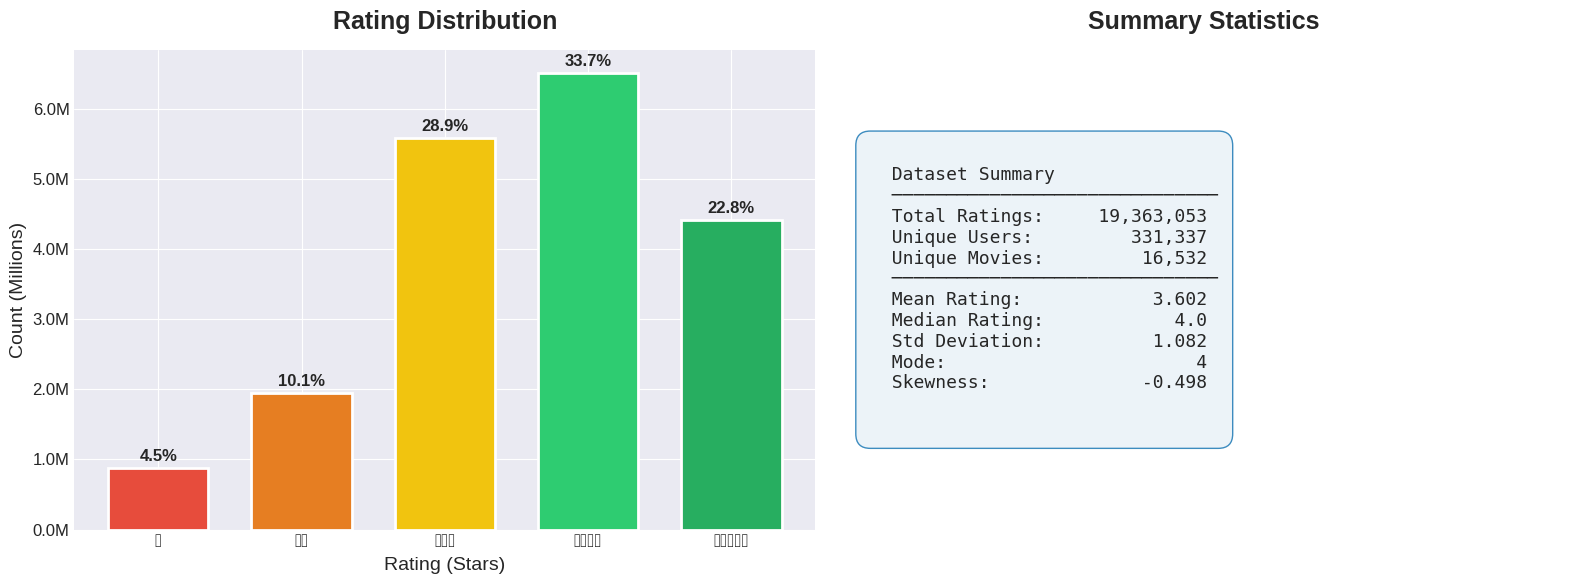

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating histogram
rating_counts = df['rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=colors,
                   edgecolor='white', linewidth=2, width=0.7)
axes[0].set_xlabel('Rating (Stars)', fontsize=14)
axes[0].set_ylabel('Count (Millions)', fontsize=14)
axes[0].set_title('Rating Distribution', fontsize=18, fontweight='bold', pad=15)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(['★', '★★', '★★★', '★★★★', '★★★★★'], fontsize=14)

# Percentage labels on bars
for bar, count in zip(bars, rating_counts.values):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
                f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Format y-axis as millions
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Summary statistics card
stats_text = (
    f"\n"
    f"  Dataset Summary\n"
    f"  {'─'*30}\n"
    f"  Total Ratings:   {len(df):>12,}\n"
    f"  Unique Users:    {df['user_id'].nunique():>12,}\n"
    f"  Unique Movies:   {df['movie_id'].nunique():>12,}\n"
    f"  {'─'*30}\n"
    f"  Mean Rating:     {df['rating'].mean():>12.3f}\n"
    f"  Median Rating:   {df['rating'].median():>12.1f}\n"
    f"  Std Deviation:   {df['rating'].std():>12.3f}\n"
    f"  Mode:            {df['rating'].mode().values[0]:>12}\n"
    f"  Skewness:        {df['rating'].skew():>12.3f}\n"
    f"  \n"
)
axes[1].text(0.05, 0.5, stats_text, transform=axes[1].transAxes, fontsize=13,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#eaf2f8', edgecolor='#2980b9', alpha=0.9))
axes[1].axis('off')
axes[1].set_title('Summary Statistics', fontsize=18, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### 4.2 User Activity Patterns

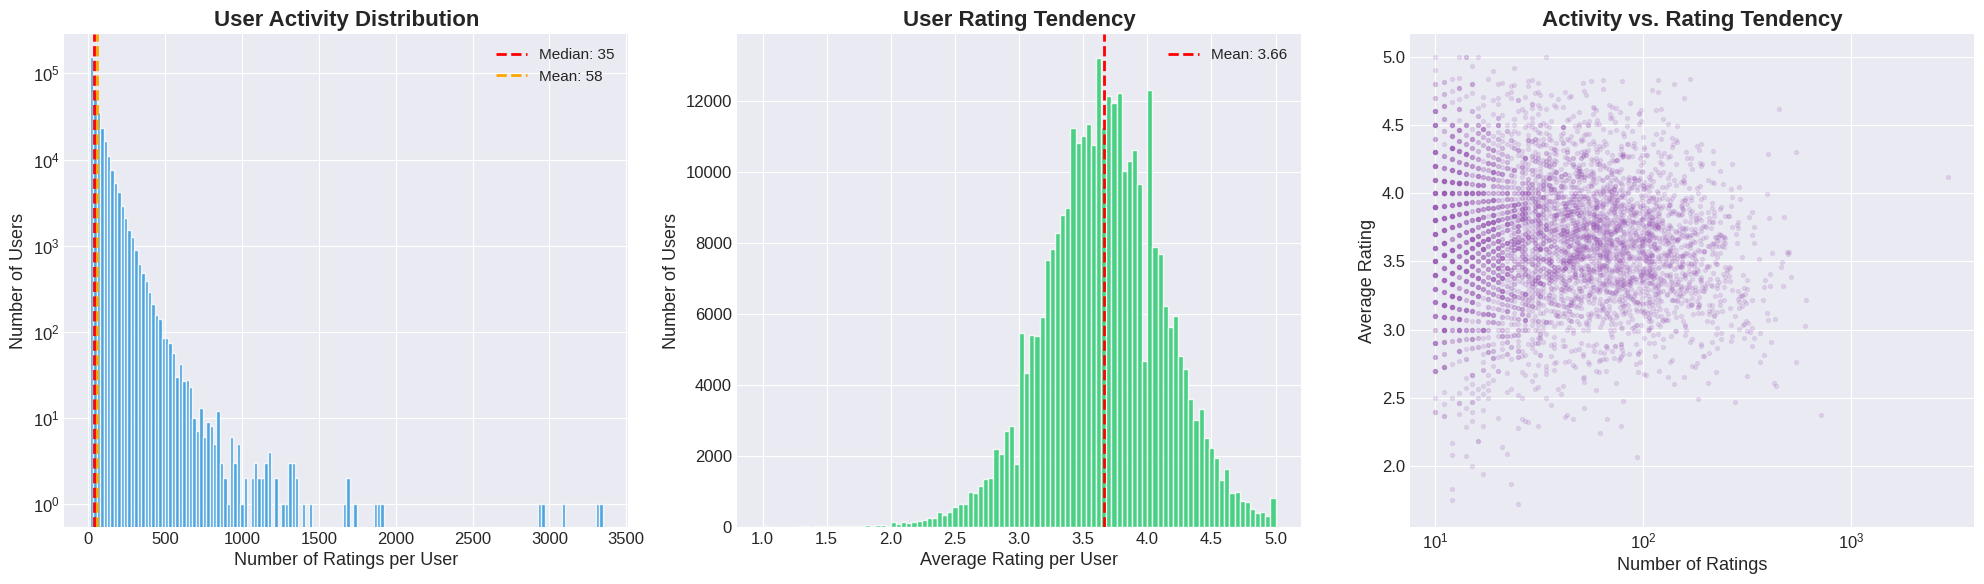


 User Activity Statistics:
   Min ratings/user:          10
   Max ratings/user:       3,347
   Mean ratings/user:       58.4
   Median ratings/user:     35.0


In [7]:
user_stats = df.groupby('user_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    std_rating=('rating', 'std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Ratings per user (log-scale)
axes[0].hist(user_stats['num_ratings'], bins=150, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Ratings per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution', fontsize=16, fontweight='bold')
axes[0].set_yscale('log')
axes[0].axvline(user_stats['num_ratings'].median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {user_stats["num_ratings"].median():.0f}')
axes[0].axvline(user_stats['num_ratings'].mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {user_stats["num_ratings"].mean():.0f}')
axes[0].legend(fontsize=11)

# 2. Average rating per user
axes[1].hist(user_stats['avg_rating'], bins=100, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Average Rating per User')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('User Rating Tendency', fontsize=16, fontweight='bold')
axes[1].axvline(user_stats['avg_rating'].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {user_stats["avg_rating"].mean():.2f}')
axes[1].legend(fontsize=11)

# 3. User activity vs average rating
sample_users = user_stats.sample(min(5000, len(user_stats)), random_state=42)
axes[2].scatter(sample_users['num_ratings'], sample_users['avg_rating'],
               alpha=0.15, s=8, color='#9b59b6')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Average Rating')
axes[2].set_title('Activity vs. Rating Tendency', fontsize=16, fontweight='bold')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

print(f'\n User Activity Statistics:')
print(f'   Min ratings/user:    {user_stats["num_ratings"].min():>8,}')
print(f'   Max ratings/user:    {user_stats["num_ratings"].max():>8,}')
print(f'   Mean ratings/user:   {user_stats["num_ratings"].mean():>8,.1f}')
print(f'   Median ratings/user: {user_stats["num_ratings"].median():>8,.1f}')

### 4.3 Content Popularity

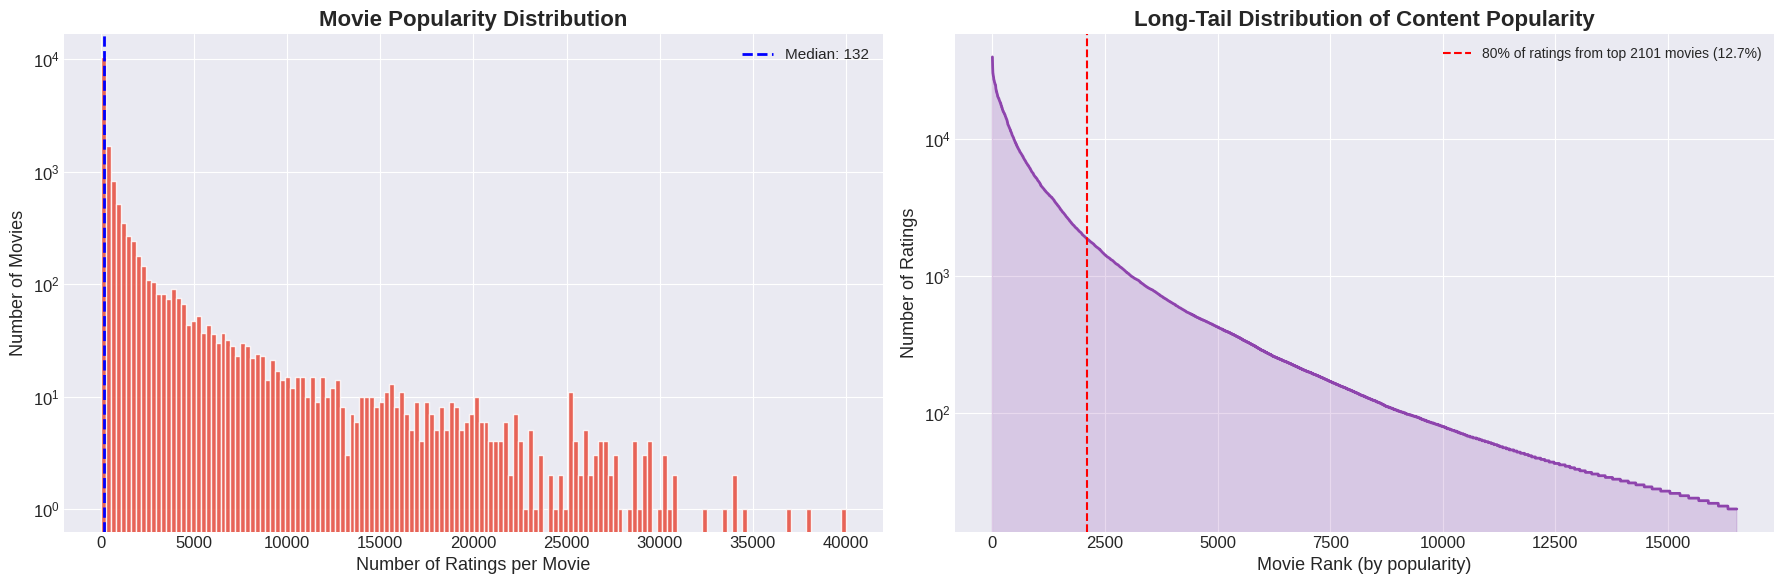


Movie Popularity Statistics:
   Min ratings/movie:          20
   Max ratings/movie:      39,992
   Mean ratings/movie:    1,171.2
   Median ratings/movie:    132.5


In [8]:
movie_stats = df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
movie_stats = movie_stats.merge(movie_titles, on='movie_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Movie popularity distribution
axes[0].hist(movie_stats['num_ratings'], bins=150, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Ratings per Movie')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Movie Popularity Distribution', fontsize=16, fontweight='bold')
axes[0].set_yscale('log')
axes[0].axvline(movie_stats['num_ratings'].median(), color='blue', linestyle='--', linewidth=2,
               label=f'Median: {movie_stats["num_ratings"].median():.0f}')
axes[0].legend(fontsize=11)

# 2. Long-tail curve
sorted_counts = movie_stats['num_ratings'].sort_values(ascending=False).values
axes[1].plot(range(len(sorted_counts)), sorted_counts, color='#8e44ad', linewidth=2)
axes[1].fill_between(range(len(sorted_counts)), sorted_counts, alpha=0.2, color='#8e44ad')
axes[1].set_xlabel('Movie Rank (by popularity)')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_title('Long-Tail Distribution of Content Popularity', fontsize=16, fontweight='bold')
axes[1].set_yscale('log')

# Mark the 80-20 split
cumsum = np.cumsum(sorted_counts)
threshold_idx = np.searchsorted(cumsum, 0.8 * cumsum[-1])
axes[1].axvline(threshold_idx, color='red', linestyle='--', linewidth=1.5,
               label=f'80% of ratings from top {threshold_idx} movies ({threshold_idx/len(sorted_counts)*100:.1f}%)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nMovie Popularity Statistics:')
print(f'   Min ratings/movie:    {movie_stats["num_ratings"].min():>8,}')
print(f'   Max ratings/movie:    {movie_stats["num_ratings"].max():>8,}')
print(f'   Mean ratings/movie:   {movie_stats["num_ratings"].mean():>8,.1f}')
print(f'   Median ratings/movie: {movie_stats["num_ratings"].median():>8,.1f}')

### 4.4 Top 20 Most Rated Movies

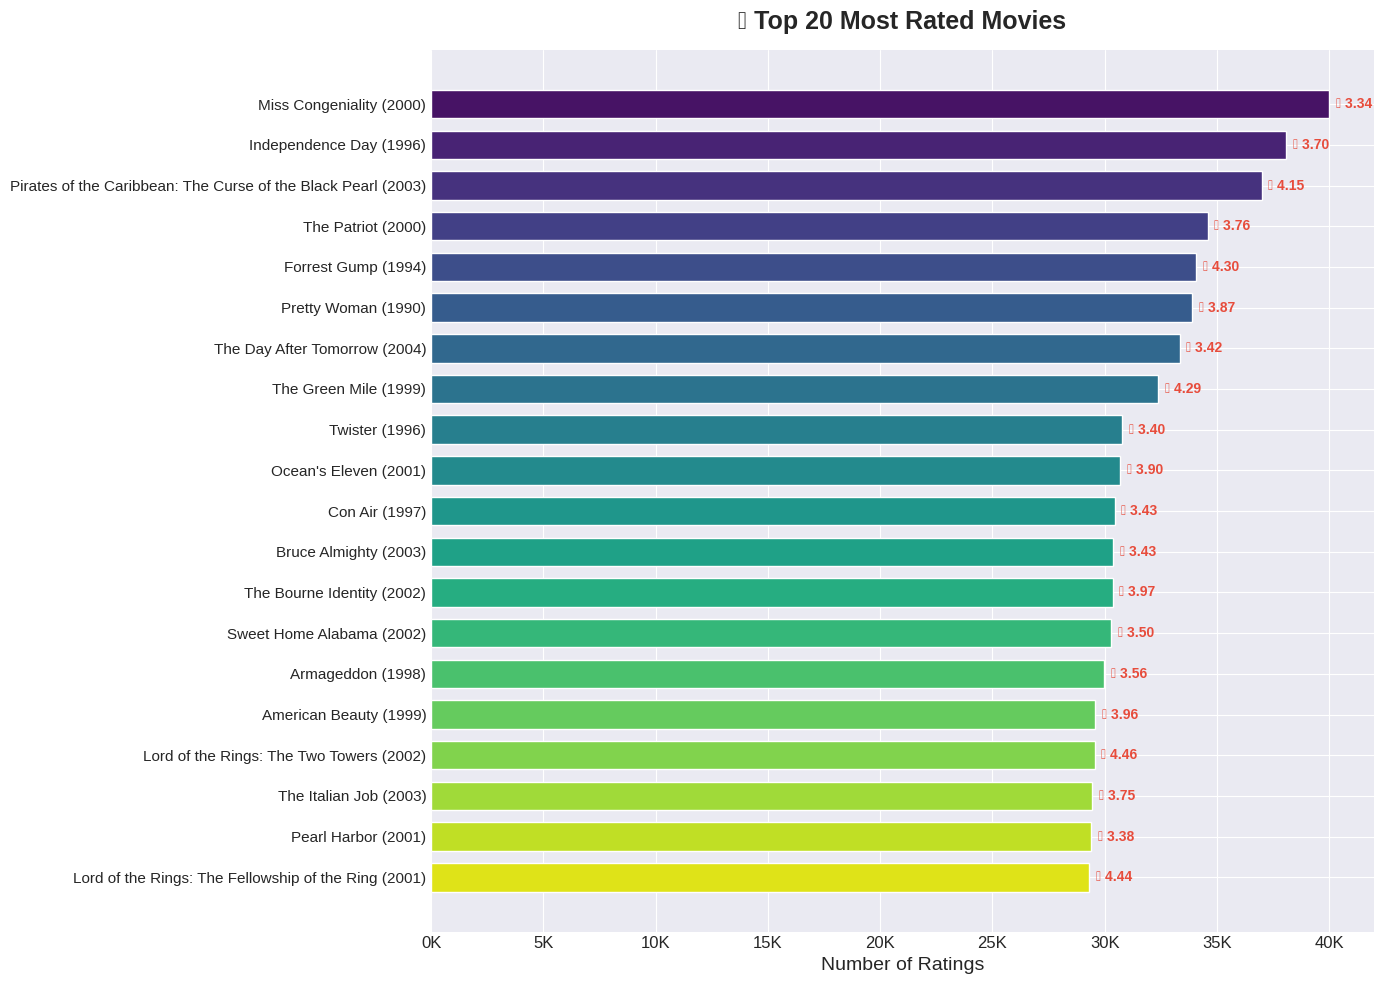

In [9]:
top_20 = movie_stats.sort_values('num_ratings', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 10))
palette = sns.color_palette('viridis', len(top_20))

bars = ax.barh(range(len(top_20)), top_20['num_ratings'].values, color=palette, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top_20)))
labels = [f"{t} ({int(y)})" if pd.notna(y) else str(t)
          for t, y in zip(top_20['title'].values, top_20['year'].values)]
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Number of Ratings', fontsize=14)
ax.set_title('🏆 Top 20 Most Rated Movies', fontsize=18, fontweight='bold', pad=15)
ax.invert_yaxis()

# Show avg rating next to each bar
for i, (count, avg) in enumerate(zip(top_20['num_ratings'].values, top_20['avg_rating'].values)):
    ax.text(count + 300, i, f'★ {avg:.2f}', va='center', fontsize=10, color='#e74c3c', fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

### 4.5 Temporal Trends

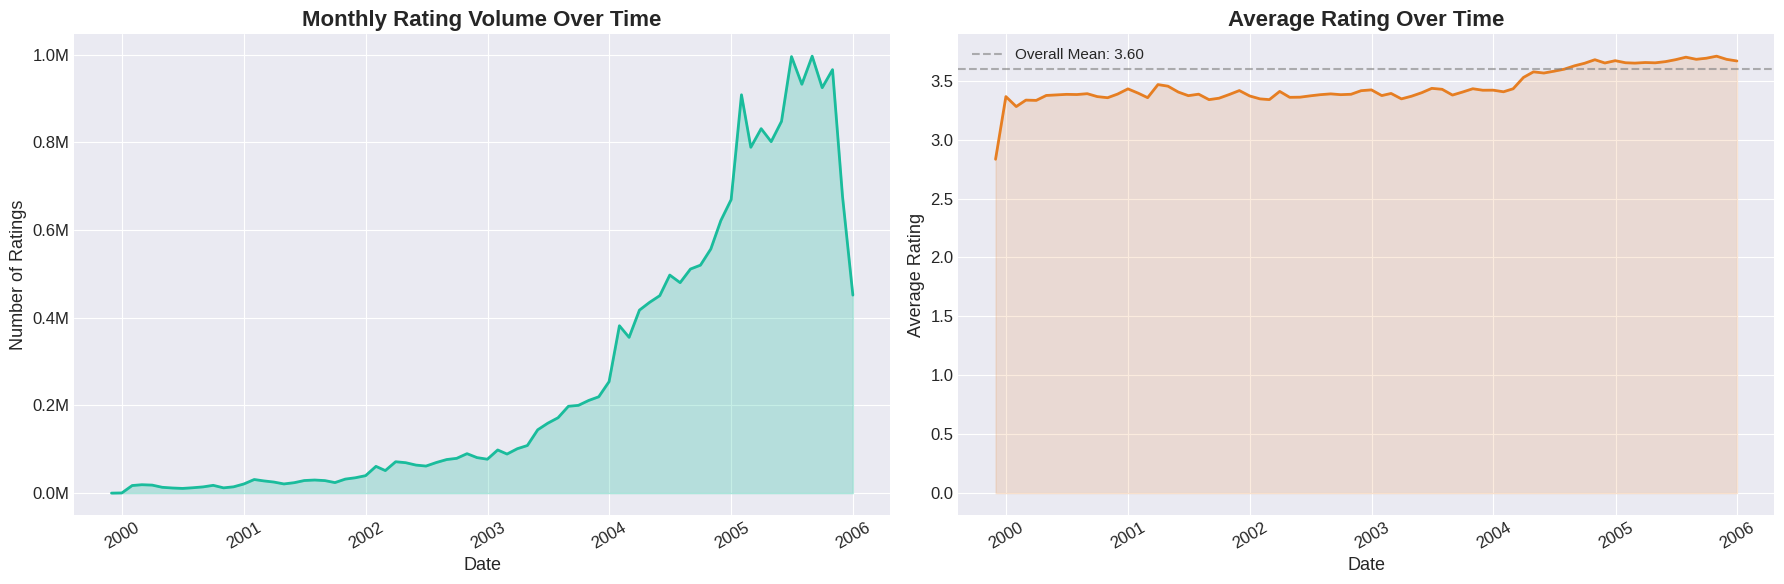

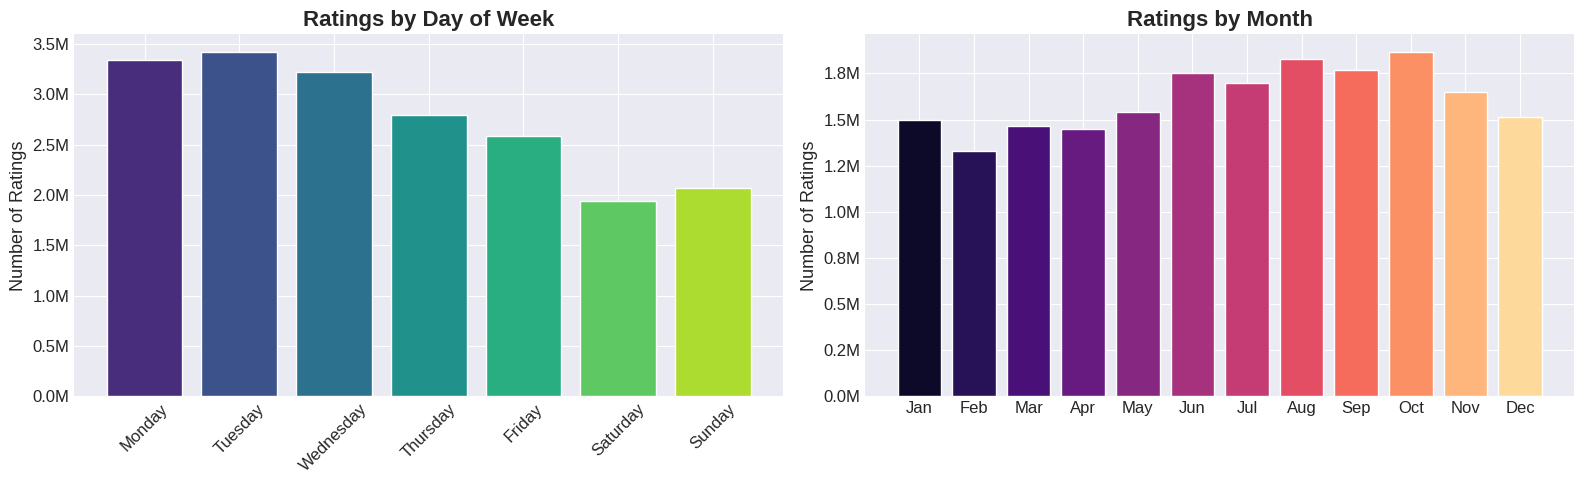

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Monthly rating volume
monthly_volume = df.set_index('date').resample('ME').size()
axes[0].plot(monthly_volume.index, monthly_volume.values, color='#1abc9c', linewidth=2)
axes[0].fill_between(monthly_volume.index, monthly_volume.values, alpha=0.25, color='#1abc9c')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Ratings')
axes[0].set_title('Monthly Rating Volume Over Time', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Average rating over time
monthly_avg = df.set_index('date').resample('ME')['rating'].mean()
axes[1].plot(monthly_avg.index, monthly_avg.values, color='#e67e22', linewidth=2)
axes[1].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.15, color='#e67e22')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Rating')
axes[1].set_title('Average Rating Over Time', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.6,
               label=f'Overall Mean: {df["rating"].mean():.2f}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Day of week analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_counts = df['date'].dt.day_name().value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex(day_order)
axes[0].bar(dow_counts.index, dow_counts.values, color=sns.color_palette('viridis', 7), edgecolor='white')
axes[0].set_ylabel('Number of Ratings')
axes[0].set_title('Ratings by Day of Week', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Monthly seasonality
month_counts = df['date'].dt.month.value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_labels, month_counts.values, color=sns.color_palette('magma', 12), edgecolor='white')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_title('Ratings by Month', fontsize=16, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### 4.6 Data Sparsity Analysis

User-Movie Matrix Dimensions
   331,337 users × 16,532 movies = 5,477,663,284 possible entries
   Actual ratings: 19,363,053
   Sparsity: 99.6465%
   Density:  0.3535%

   For every 1,000 possible user-movie pairs, only ~3.5 have actual ratings.


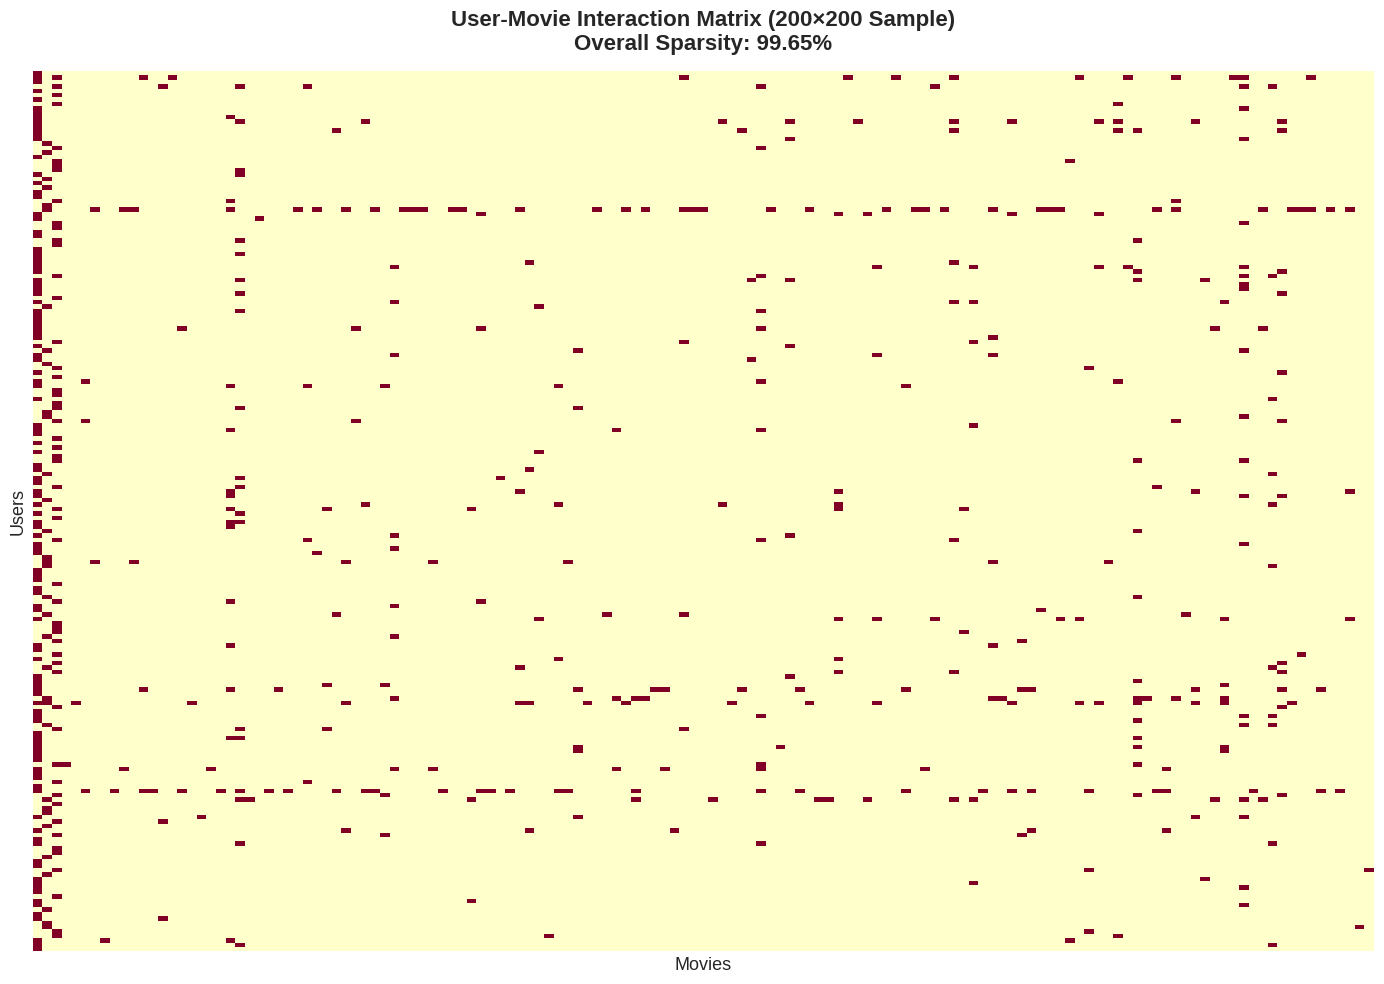

In [11]:
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
total_possible = n_users * n_movies
sparsity = 1 - n_ratings / total_possible

print(f'User-Movie Matrix Dimensions')
print(f'   {n_users:,} users × {n_movies:,} movies = {total_possible:,.0f} possible entries')
print(f'   Actual ratings: {n_ratings:,}')
print(f'   Sparsity: {sparsity * 100:.4f}%')
print(f'   Density:  {(1 - sparsity) * 100:.4f}%')
print(f'\n   For every 1,000 possible user-movie pairs, only ~{(1-sparsity)*1000:.1f} have actual ratings.')

# Visualize a sample of the interaction matrix
sample_users = sorted(df['user_id'].unique()[:200])
sample_movies = sorted(df['movie_id'].unique()[:200])
sample_df = df[(df['user_id'].isin(sample_users)) & (df['movie_id'].isin(sample_movies))]

matrix_sample = sample_df.pivot_table(index='user_id', columns='movie_id', values='rating')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(matrix_sample.notna().astype(int), cmap='YlOrRd', cbar=False, ax=ax,
           xticklabels=False, yticklabels=False)
ax.set_title(f'User-Movie Interaction Matrix (200×200 Sample)\nOverall Sparsity: {sparsity*100:.2f}%',
            fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Movies', fontsize=13)
ax.set_ylabel('Users', fontsize=13)
plt.tight_layout()
plt.show()

### 4.7 Movie Release Year Analysis

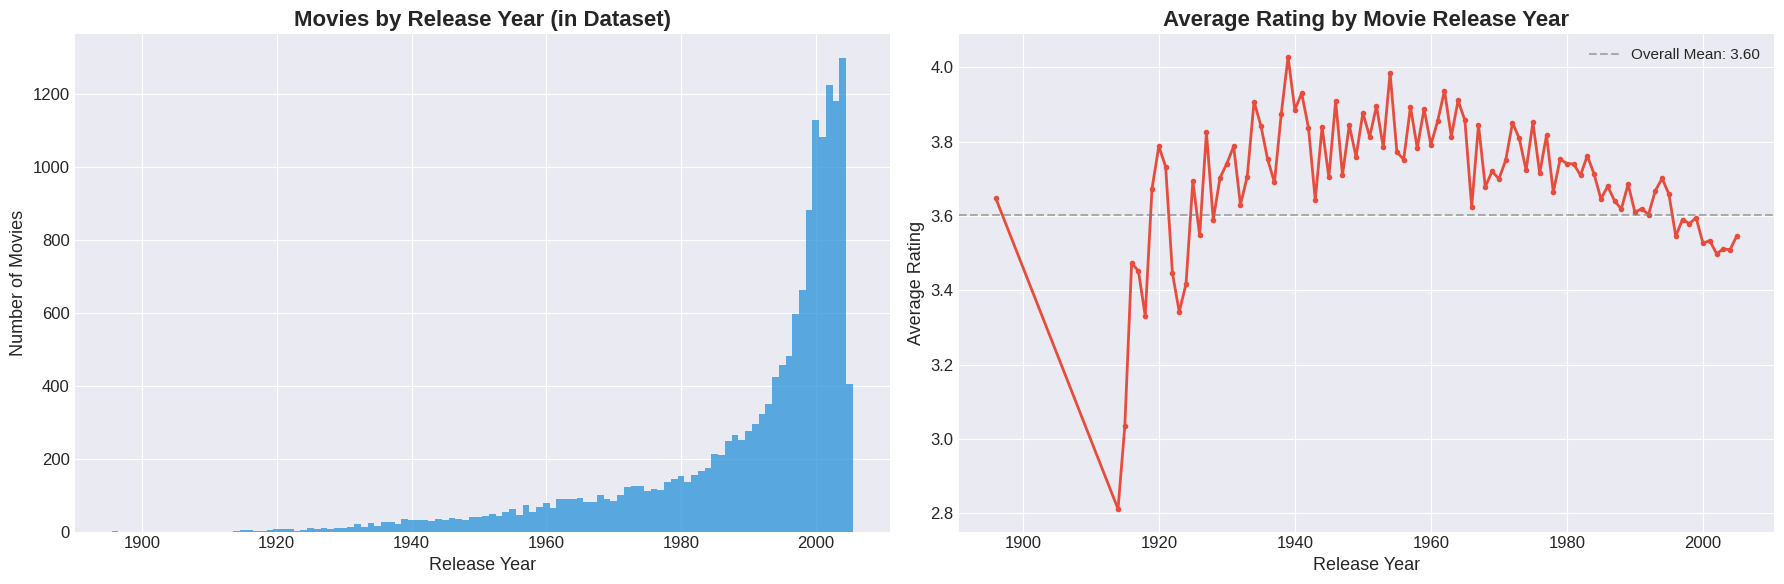

In [12]:
df_with_year = df.merge(movie_titles[['movie_id', 'year']], on='movie_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Number of movies by release year
movies_per_year = movie_stats.dropna(subset=['year']).groupby('year').size()
axes[0].bar(movies_per_year.index, movies_per_year.values, color='#3498db', alpha=0.8, width=1)
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Movies by Release Year (in Dataset)', fontsize=16, fontweight='bold')

# Average rating by release year
year_avg = df_with_year.dropna(subset=['year']).groupby('year')['rating'].mean()
axes[1].plot(year_avg.index, year_avg.values, color='#e74c3c', linewidth=2, marker='o', markersize=3)
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_title('Average Rating by Movie Release Year', fontsize=16, fontweight='bold')
axes[1].axhline(df['rating'].mean(), color='gray', linestyle='--', alpha=0.6,
               label=f'Overall Mean: {df["rating"].mean():.2f}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 5. Data Preparation for Modeling

We prepare the data using the **Surprise** library, which provides efficient implementations of collaborative filtering algorithms.

**Train/Test Split Strategy:**
- 80/20 random split
- Random state = 42 for reproducibility
- This ensures both training and test sets contain ratings from a representative mix of users and items

In [13]:
# Build Surprise dataset
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# 80/20 train-test split
trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=42)

print(f' Data Preparation Complete')
print(f'   Training set:  {trainset.n_ratings:>12,} ratings')
print(f'   Test set:      {len(testset):>12,} ratings')
print(f'   Training users: {trainset.n_users:>11,}')
print(f'   Training items: {trainset.n_items:>11,}')
print(f'\n   Split ratio: {trainset.n_ratings/(trainset.n_ratings+len(testset))*100:.1f}% train / {len(testset)/(trainset.n_ratings+len(testset))*100:.1f}% test')

 Data Preparation Complete
   Training set:    15,490,442 ratings
   Test set:         3,872,611 ratings
   Training users:     331,337
   Training items:      16,532

   Split ratio: 80.0% train / 20.0% test


---
## 6. Model 1: SVD (Singular Value Decomposition)

**SVD** is a matrix factorization technique that decomposes the user-item interaction matrix into lower-dimensional latent factor matrices. Each user and item is represented by a vector in latent space, and the predicted rating is the dot product of user and item vectors (plus bias terms).

**Why SVD?**
- Won the Netflix Prize competition (as part of an ensemble)
- Excellent at handling sparse data by learning compact representations
- Captures both global biases and latent user/item interactions
- Computationally efficient for training and prediction

**Hyperparameters:**
- `n_factors=100`: Dimensionality of latent space
- `n_epochs=20`: Number of SGD iterations
- `lr_all=0.005`: Learning rate
- `reg_all=0.02`: L2 regularization

In [14]:
print('Training SVD Model...')
print('=' * 60)

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42,
    verbose=True
)

start_time = time.time()
svd_model.fit(trainset)
svd_train_time = time.time() - start_time

print(f'\n SVD training complete in {svd_train_time:.2f} seconds')

# Evaluate on test set
print('\n Evaluating on test set...')
start_time = time.time()
svd_predictions = svd_model.test(testset)
svd_pred_time = time.time() - start_time

svd_rmse = accuracy.rmse(svd_predictions, verbose=False)
svd_mae = accuracy.mae(svd_predictions, verbose=False)

print(f'\n{"─"*40}')
print(f'  SVD Results')
print(f'{"─"*40}')
print(f'  RMSE:            {svd_rmse:.4f}')
print(f'  MAE:             {svd_mae:.4f}')
print(f'  Training Time:   {svd_train_time:.2f}s')
print(f'  Prediction Time: {svd_pred_time:.2f}s')
print(f'{"─"*40}')

Training SVD Model...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

 SVD training complete in 292.14 seconds

 Evaluating on test set...

────────────────────────────────────────
  SVD Results
────────────────────────────────────────
  RMSE:            0.9064
  MAE:             0.7051
  Training Time:   292.14s
  Prediction Time: 50.71s
────────────────────────────────────────


---
## 7. Model 2: KNN Item-Based Collaborative Filtering

**Item-Based CF** recommends items similar to what a user has liked before. It computes pairwise similarities between items based on user rating patterns, then predicts ratings using a weighted average of similar items' ratings.

**Why KNN Item-Based CF?**
- Classic recommendation approach with strong theoretical foundation
- Highly interpretable — can explain "Why" an item was recommended
- Item similarities are more stable than user similarities (items change less than users)
- Provides a good comparison baseline against matrix factorization

**Configuration:**
- `KNNBaseline`: Incorporates baseline estimates (user/item biases) for improved accuracy
- `pearson_baseline` similarity: Accounts for rating bias differences between items
- `user_based=False`: Item-based (as opposed to user-based)
- `k=40`: Number of neighbors used for prediction

In [15]:
print('Training KNN Item-Based CF Model...')
print('=' * 60)

sim_options = {
    'name': 'pearson_baseline',
    'user_based': False,
    'min_support': 5
}

knn_model = KNNBaseline(
    k=40,
    sim_options=sim_options,
    verbose=True
)

start_time = time.time()
knn_model.fit(trainset)
knn_train_time = time.time() - start_time

print(f'\nKNN training complete in {knn_train_time:.2f} seconds')

# Evaluate on test set
print('\nEvaluating on test set...')
start_time = time.time()
knn_predictions = knn_model.test(testset)
knn_pred_time = time.time() - start_time

knn_rmse = accuracy.rmse(knn_predictions, verbose=False)
knn_mae = accuracy.mae(knn_predictions, verbose=False)

print(f'\n{"─"*40}')
print(f'  KNN Item-Based CF Results')
print(f'{"─"*40}')
print(f'  RMSE:            {knn_rmse:.4f}')
print(f'  MAE:             {knn_mae:.4f}')
print(f'  Training Time:   {knn_train_time:.2f}s')
print(f'  Prediction Time: {knn_pred_time:.2f}s')
print(f'{"─"*40}')

Training KNN Item-Based CF Model...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

KNN training complete in 293.98 seconds

Evaluating on test set...

────────────────────────────────────────
  KNN Item-Based CF Results
────────────────────────────────────────
  RMSE:            0.8957
  MAE:             0.6909
  Training Time:   293.98s
  Prediction Time: 560.29s
────────────────────────────────────────


---
## 8. Model Comparison

Side-by-side comparison of SVD and KNN Item-Based CF across multiple dimensions.


Model Comparison Table
             Metric        SVD  KNN Item-Based CF Winner
             RMSE ↓   0.906388           0.895696  KNN ✓
              MAE ↓   0.705103           0.690902  KNN ✓
  Training Time (s) 292.136527         293.984873  SVD ✓
Prediction Time (s)  50.709603         560.291719  SVD ✓


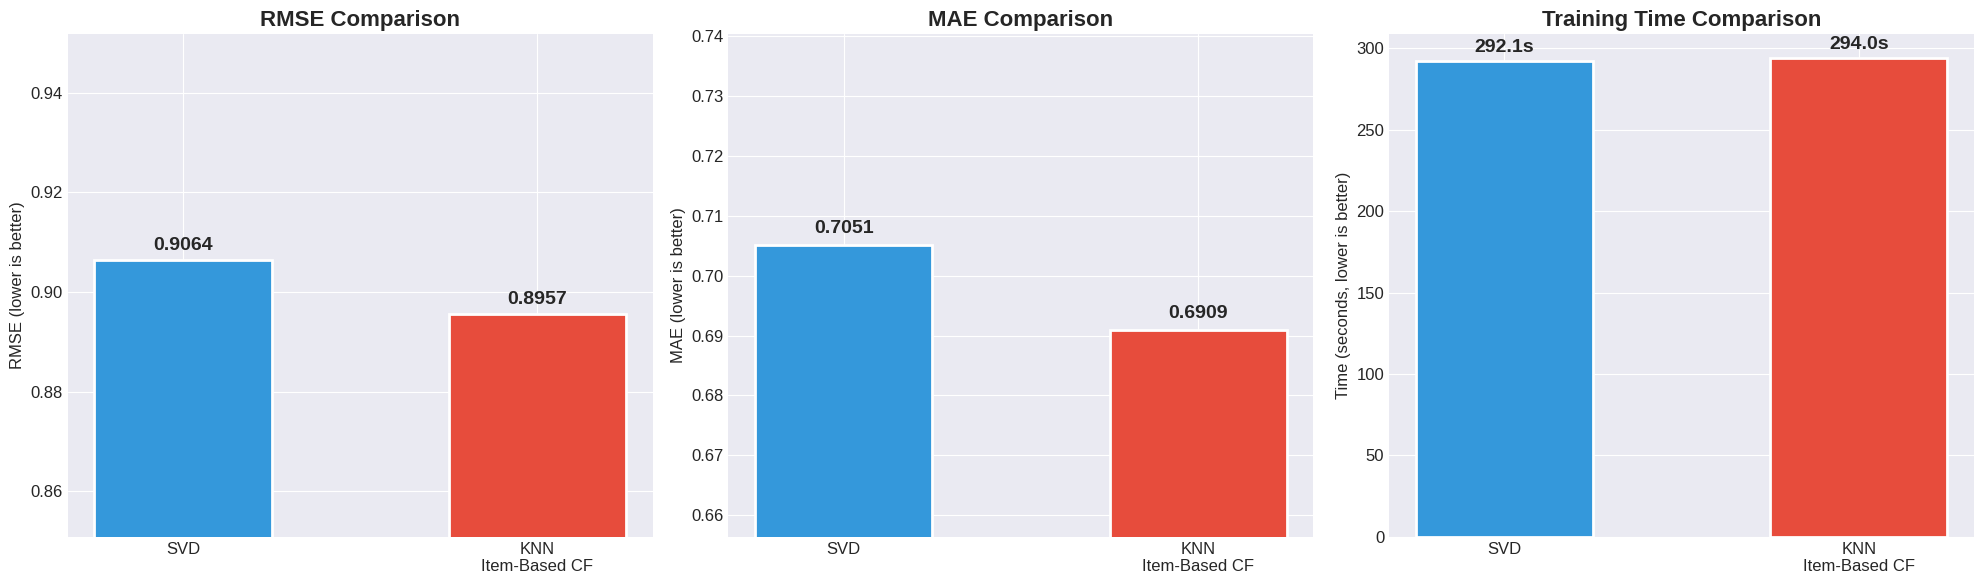

In [26]:
# Comparison table
comparison_df = pd.DataFrame({
    'Metric': ['RMSE ↓', 'MAE ↓', 'Training Time (s)', 'Prediction Time (s)'],
    'SVD': [svd_rmse, svd_mae, svd_train_time, svd_pred_time],
    'KNN Item-Based CF': [knn_rmse, knn_mae, knn_train_time, knn_pred_time]
})

# Determine winner for each metric
winners = []
for _, row in comparison_df.iterrows():
    if row['Metric'].endswith('↓'):
        winners.append('SVD ✓' if row['SVD'] < row['KNN Item-Based CF'] else 'KNN ✓')
    else:
        winners.append('SVD ✓' if row['SVD'] < row['KNN Item-Based CF'] else 'KNN ✓')
comparison_df['Winner'] = winners

print('\nModel Comparison Table')
print('=' * 70)
print(comparison_df.to_string(index=False))
print('=' * 70)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models = ['SVD', 'KNN\nItem-Based CF']
colors = ['#3498db', '#e74c3c']

# RMSE
vals = [svd_rmse, knn_rmse]
bars = axes[0].bar(models, vals, color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[0].set_ylabel('RMSE (lower is better)', fontsize=12)
axes[0].set_title('RMSE Comparison', fontsize=16, fontweight='bold')
axes[0].set_ylim(min(vals) * 0.95, max(vals) * 1.05)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=14, fontweight='bold')

# MAE
vals = [svd_mae, knn_mae]
bars = axes[1].bar(models, vals, color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[1].set_ylabel('MAE (lower is better)', fontsize=12)
axes[1].set_title('MAE Comparison', fontsize=16, fontweight='bold')
axes[1].set_ylim(min(vals) * 0.95, max(vals) * 1.05)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=14, fontweight='bold')

# Training Time
vals = [svd_train_time, knn_train_time]
bars = axes[2].bar(models, vals, color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[2].set_ylabel('Time (seconds, lower is better)', fontsize=12)
axes[2].set_title('Training Time Comparison', fontsize=16, fontweight='bold')
for bar, val in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.1f}s', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



---
## 9. Ranking Evaluation: MAP@10 & Additional Metrics

Beyond rating prediction accuracy (RMSE), we evaluate **recommendation ranking quality** using:

| Metric | Description |
|--------|-------------|
| **MAP@10** | Mean Average Precision at 10 — measures how well relevant items are ranked |
| **Precision@10** | Fraction of top-10 recommendations that are relevant |
| **Recall@10** | Fraction of all relevant items captured in top-10 |
| **NDCG@10** | Normalized Discounted Cumulative Gain — position-aware ranking quality |
| **Hit Rate@10** | Fraction of users with at least 1 relevant item in top-10 |
| **Coverage** | Fraction of catalog items appearing in any user's top-10 |

**Relevance Definition:** A movie is considered **relevant** if the user's actual rating ≥ **3.5**.

**Methodology:**
1. For each test user, collect all their test set ratings
2. Rank items by predicted rating (descending)
3. Take the top-10 items
4. Compute metrics against ground truth relevance
5. Average across a sample of 5,000 users for computational efficiency

In [17]:
RELEVANCE_THRESHOLD = 3.5
K = 10
MAX_USERS_FOR_RANKING = 5000  # Sample size for ranking metric computation

def compute_ranking_metrics(predictions, k=10, threshold=3.5, max_users=5000):
    """
    Compute comprehensive ranking metrics from Surprise predictions.
    
    For each user:
    1. Sort their test items by predicted rating (descending)
    2. Take top-K predictions
    3. Compute metrics against ground truth (actual rating >= threshold)
    
    Returns dict of averaged metrics.
    """
    # Group predictions by user
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, true_r, est))
    
    # Filter to users with enough test items
    eligible_users = {uid: preds for uid, preds in user_preds.items() if len(preds) >= k}
    
    # Sample users if needed
    user_ids = list(eligible_users.keys())
    if len(user_ids) > max_users:
        np.random.seed(42)
        user_ids = list(np.random.choice(user_ids, max_users, replace=False))
    
    precisions, recalls, aps, ndcgs, hits = [], [], [], [], []
    all_recommended_items = set()
    
    for uid in user_ids:
        preds = eligible_users[uid]
        
        # Sort by predicted rating (descending)
        preds.sort(key=lambda x: x[2], reverse=True)
        top_k = preds[:k]
        
        # Count total relevant items for this user
        n_relevant = sum(1 for _, true_r, _ in preds if true_r >= threshold)
        
        if n_relevant == 0:
            continue  # Skip users with no relevant items
        
        # Track recommended items for coverage
        for iid, _, _ in top_k:
            all_recommended_items.add(iid)
        
        # Precision@K: fraction of top-K that are relevant
        n_relevant_in_topk = sum(1 for _, true_r, _ in top_k if true_r >= threshold)
        precision = n_relevant_in_topk / k
        precisions.append(precision)
        
        # Recall@K: fraction of relevant items found in top-K
        recall = n_relevant_in_topk / n_relevant
        recalls.append(recall)
        
        # Hit Rate: at least 1 relevant item in top-K
        hits.append(1 if n_relevant_in_topk > 0 else 0)
        
        # Average Precision@K (AP@K)
        ap = 0.0
        n_rel_found = 0
        for i, (_, true_r, _) in enumerate(top_k):
            if true_r >= threshold:
                n_rel_found += 1
                ap += n_rel_found / (i + 1)
        ap = ap / min(n_relevant, k)
        aps.append(ap)
        
        # NDCG@K
        dcg = 0.0
        for i, (_, true_r, _) in enumerate(top_k):
            if true_r >= threshold:
                dcg += 1.0 / np.log2(i + 2)
        
        # Ideal DCG: best possible ranking
        ideal_rels = sorted([1 if true_r >= threshold else 0 for _, true_r, _ in preds], reverse=True)[:k]
        idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_rels) if rel > 0)
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcgs.append(ndcg)
    
    return {
        'MAP@10': np.mean(aps),
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs),
        'Hit Rate@10': np.mean(hits),
        'Coverage': len(all_recommended_items),
        'Users Evaluated': len(aps)
    }

print(f'Computing ranking metrics (sampling {MAX_USERS_FOR_RANKING:,} users)...')
print(f'Relevance threshold: actual rating >= {RELEVANCE_THRESHOLD}')
print()

# SVD Ranking Metrics
print('Computing SVD ranking metrics...')
start = time.time()
svd_ranking = compute_ranking_metrics(svd_predictions, k=K, threshold=RELEVANCE_THRESHOLD,
                                       max_users=MAX_USERS_FOR_RANKING)
print(f'   Done in {time.time()-start:.1f}s')

# KNN Ranking Metrics
print('Computing KNN ranking metrics...')
start = time.time()
knn_ranking = compute_ranking_metrics(knn_predictions, k=K, threshold=RELEVANCE_THRESHOLD,
                                       max_users=MAX_USERS_FOR_RANKING)
print(f'   Done in {time.time()-start:.1f}s')

Computing ranking metrics (sampling 5,000 users)...
Relevance threshold: actual rating >= 3.5

Computing SVD ranking metrics...
   Done in 5.5s
Computing KNN ranking metrics...
   Done in 5.1s



RANKING METRICS COMPARISON
  Relevance: actual rating >= 3.5 | K = 10
  Users evaluated: 4,990
                  Metric           SVD KNN Item-Based CF
    MAP@10 ↑ (MANDATORY)        0.7071            0.7277
          Precision@10 ↑        0.6933            0.7043
             Recall@10 ↑        0.6808            0.6906
               NDCG@10 ↑        0.8149            0.8305
           Hit Rate@10 ↑        0.9990            0.9994
Coverage (out of 16,532) 5,329 (32.2%)     5,540 (33.5%)


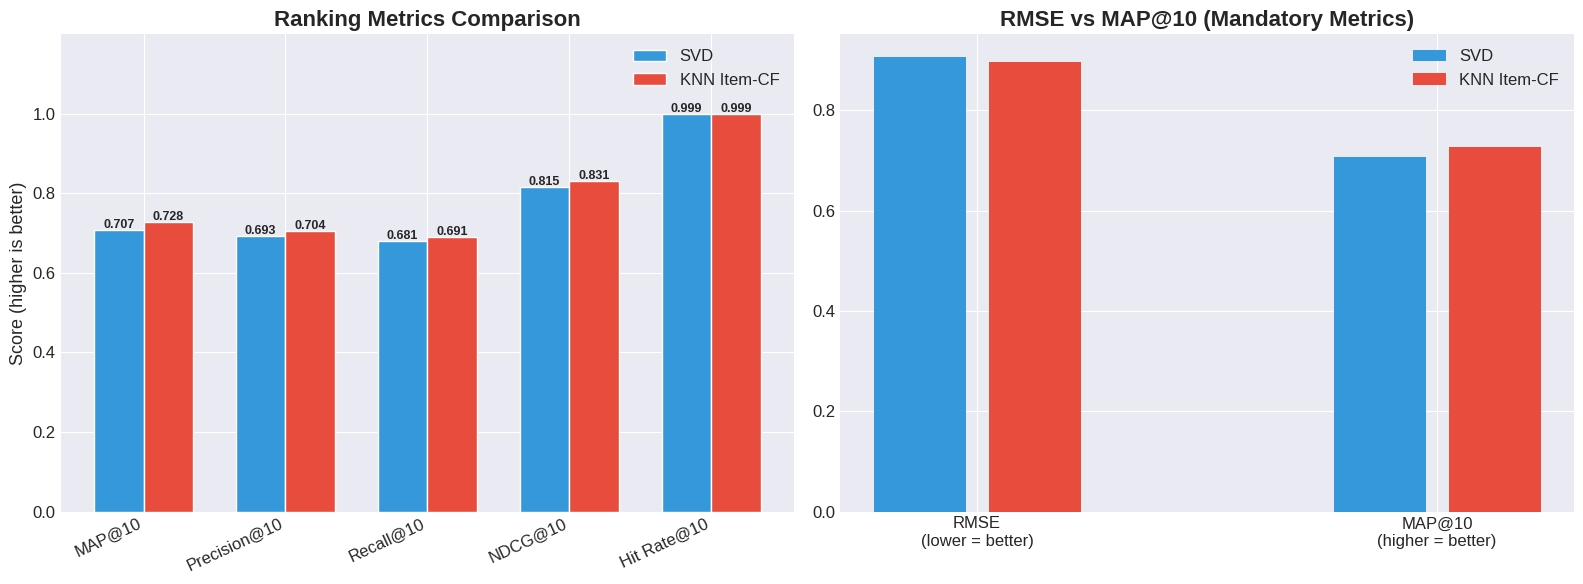

In [27]:
# Display ranking metrics comparison
n_total_items = df['movie_id'].nunique()

ranking_comparison = pd.DataFrame({
    'Metric': [
        'MAP@10 ↑ (MANDATORY)',
        'Precision@10 ↑',
        'Recall@10 ↑',
        'NDCG@10 ↑',
        'Hit Rate@10 ↑',
        f'Coverage (out of {n_total_items:,})'
    ],
    'SVD': [
        f"{svd_ranking['MAP@10']:.4f}",
        f"{svd_ranking['Precision@10']:.4f}",
        f"{svd_ranking['Recall@10']:.4f}",
        f"{svd_ranking['NDCG@10']:.4f}",
        f"{svd_ranking['Hit Rate@10']:.4f}",
        f"{svd_ranking['Coverage']:,} ({svd_ranking['Coverage']/n_total_items*100:.1f}%)"
    ],
    'KNN Item-Based CF': [
        f"{knn_ranking['MAP@10']:.4f}",
        f"{knn_ranking['Precision@10']:.4f}",
        f"{knn_ranking['Recall@10']:.4f}",
        f"{knn_ranking['NDCG@10']:.4f}",
        f"{knn_ranking['Hit Rate@10']:.4f}",
        f"{knn_ranking['Coverage']:,} ({knn_ranking['Coverage']/n_total_items*100:.1f}%)"
    ]
})

print('\n' + '=' * 75)
print('RANKING METRICS COMPARISON')
print(f'  Relevance: actual rating >= {RELEVANCE_THRESHOLD} | K = {K}')
print(f'  Users evaluated: {svd_ranking["Users Evaluated"]:,}')
print('=' * 75)
print(ranking_comparison.to_string(index=False))
print('=' * 75)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['MAP@10', 'Precision@10', 'Recall@10', 'NDCG@10', 'Hit Rate@10']
svd_vals = [svd_ranking[m] for m in metrics]
knn_vals = [knn_ranking[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, svd_vals, width, label='SVD', color='#3498db', edgecolor='white')
bars2 = axes[0].bar(x + width/2, knn_vals, width, label='KNN Item-CF', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=25, ha='right')
axes[0].set_ylabel('Score (higher is better)')
axes[0].set_title('Ranking Metrics Comparison', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, max(max(svd_vals), max(knn_vals)) * 1.2)

for bar, val in zip(bars1, svd_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, knn_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Combined comparison: RMSE + MAP@10
combined = pd.DataFrame({
    'Metric': ['RMSE (Rating Pred.)\n↓ lower is better', 'MAP@10 (Ranking)\n↑ higher is better'],
    'SVD': [svd_rmse, svd_ranking['MAP@10']],
    'KNN': [knn_rmse, knn_ranking['MAP@10']]
})

axes[1].bar([0, 2], [svd_rmse, svd_ranking['MAP@10']], width=0.4, label='SVD', color='#3498db')
axes[1].bar([0.5, 2.5], [knn_rmse, knn_ranking['MAP@10']], width=0.4, label='KNN Item-CF', color='#e74c3c')
axes[1].set_xticks([0.25, 2.25])
axes[1].set_xticklabels(['RMSE\n(lower = better)', 'MAP@10\n(higher = better)'], fontsize=12)
axes[1].set_title('RMSE vs MAP@10 (Mandatory Metrics)', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

---
## 10. Top-K Recommendation Generation

Generate **Top-10 personalized recommendations** for sample users and analyze recommendation quality.

In [19]:
def get_top_n_recommendations(model, trainset, user_id, movie_titles_df, n=10):
    """
    Generate top-N recommendations for a given user.
    
    Predicts ratings for all items the user hasn't rated in the training set,
    then returns the top-N items with highest predicted ratings.
    """
    # Get items the user has already rated in training
    try:
        user_inner_id = trainset.to_inner_uid(user_id)
        rated_items = set(trainset.to_raw_iid(iid) for iid, _ in trainset.ur[user_inner_id])
    except ValueError:
        rated_items = set()
    
    # Predict for all unrated items
    all_items = set(trainset.to_raw_iid(i) for i in trainset.all_items())
    unrated_items = all_items - rated_items
    
    predictions = []
    for item_id in unrated_items:
        pred = model.predict(user_id, item_id)
        predictions.append((item_id, pred.est))
    
    # Sort by predicted rating and take top-N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]
    
    # Build results with movie metadata
    results = []
    for rank, (movie_id, pred_rating) in enumerate(top_n, 1):
        row = movie_titles_df[movie_titles_df['movie_id'] == movie_id]
        title = row['title'].values[0] if len(row) > 0 else f'Movie {movie_id}'
        year = row['year'].values[0] if len(row) > 0 and pd.notna(row['year'].values[0]) else 'N/A'
        results.append({
            'Rank': rank,
            'Movie ID': movie_id,
            'Title': title,
            'Year': year,
            'Predicted Rating': f'{pred_rating:.3f}'
        })
    
    return pd.DataFrame(results)


def get_user_history(user_id, df, movie_titles_df, n=10):
    """Get a user's top-rated movies from the dataset."""
    user_df = df[df['user_id'] == user_id].sort_values('rating', ascending=False).head(n)
    user_df = user_df.merge(movie_titles_df[['movie_id', 'title', 'year']], on='movie_id', how='left')
    return user_df[['movie_id', 'title', 'year', 'rating']]


# Select sample users with varying activity levels
user_activity = df.groupby('user_id').size().reset_index(name='n_ratings')

# Pick users from different activity percentiles
percentiles = [25, 50, 75, 90, 99]
sample_user_ids = []
for p in percentiles:
    threshold = np.percentile(user_activity['n_ratings'], p)
    candidates = user_activity[
        (user_activity['n_ratings'] >= threshold * 0.9) &
        (user_activity['n_ratings'] <= threshold * 1.1)
    ]['user_id'].values
    if len(candidates) > 0:
        np.random.seed(42 + p)
        sample_user_ids.append(np.random.choice(candidates))

print(f'Selected {len(sample_user_ids)} sample users from different activity levels:')
for uid in sample_user_ids:
    n = len(df[df['user_id'] == uid])
    print(f'  User {uid}: {n:,} ratings')

Selected 5 sample users from different activity levels:
  User 224073: 18 ratings
  User 464075: 34 ratings
  User 1484035: 67 ratings
  User 878036: 129 ratings
  User 1769330: 288 ratings


In [20]:
# Generate and display recommendations for each sample user
for i, uid in enumerate(sample_user_ids):
    n_ratings = len(df[df['user_id'] == uid])
    avg_rating = df[df['user_id'] == uid]['rating'].mean()
    
    print(f'\n{"═"*80}')
    print(f'  👤 User {uid} | {n_ratings:,} ratings | Avg rating: {avg_rating:.2f}')
    print(f'{"═"*80}')
    
    # User's favorite movies (history)
    print(f'\n  📜 Top-Rated Movies in History (Ground Truth):')
    history = get_user_history(uid, df, movie_titles, n=8)
    for _, row in history.iterrows():
        year_str = f"({int(row['year'])})" if pd.notna(row['year']) else ''
        print(f'     ★ {row["rating"]:.0f}  {row["title"]} {year_str}')
    
    # SVD Recommendations
    print(f'\n  🎯 SVD Top-10 Recommendations:')
    svd_recs = get_top_n_recommendations(svd_model, trainset, uid, movie_titles, n=10)
    for _, row in svd_recs.iterrows():
        year_str = f"({int(row['Year'])})" if row['Year'] != 'N/A' else ''
        print(f'     {row["Rank"]:>2}. [{row["Predicted Rating"]}] {row["Title"]} {year_str}')
    
    # KNN Recommendations
    print(f'\n  🎯 KNN Item-Based CF Top-10 Recommendations:')
    knn_recs = get_top_n_recommendations(knn_model, trainset, uid, movie_titles, n=10)
    for _, row in knn_recs.iterrows():
        year_str = f"({int(row['Year'])})" if row['Year'] != 'N/A' else ''
        print(f'     {row["Rank"]:>2}. [{row["Predicted Rating"]}] {row["Title"]} {year_str}')
    
    # Compare overlap
    svd_set = set(svd_recs['Movie ID'])
    knn_set = set(knn_recs['Movie ID'])
    overlap = svd_set & knn_set
    print(f'\n  📊 Overlap: {len(overlap)}/10 movies appear in both models\' recommendations')


════════════════════════════════════════════════════════════════════════════════
  👤 User 224073 | 18 ratings | Avg rating: 3.61
════════════════════════════════════════════════════════════════════════════════

  📜 Top-Rated Movies in History (Ground Truth):
     ★ 4  Empire (2002)
     ★ 4  Half Past Dead (2002)
     ★ 4  Phone Booth (2003)
     ★ 4  XXX: Special Edition (2002)
     ★ 4  Mind Hunters (2004)
     ★ 4  Drumline (2002)
     ★ 4  Basic (2003)
     ★ 4  Blue Crush (2002)

  🎯 SVD Top-10 Recommendations:
      1. [5.000] Monk: Season 2 (2003)
      2. [5.000] Curb Your Enthusiasm: Season 3 (2002)
      3. [5.000] Queer as Folk: Season 3 (2003)
      4. [5.000] Movie 13504 
      5. [4.995] Absolutely Fabulous: Series 2 (1994)
      6. [4.968] The Lord of the Rings: The Fellowship of the Ring: Extended Edition (2001)
      7. [4.961] Lord of the Rings: The Return of the King: Extended Edition (2003)
      8. [4.952] Sense and Sensibility (1995)
      9. [4.951] Ken Burns' C

### 10.1 Success & Failure Case Analysis

Prediction Error Analysis (SVD)


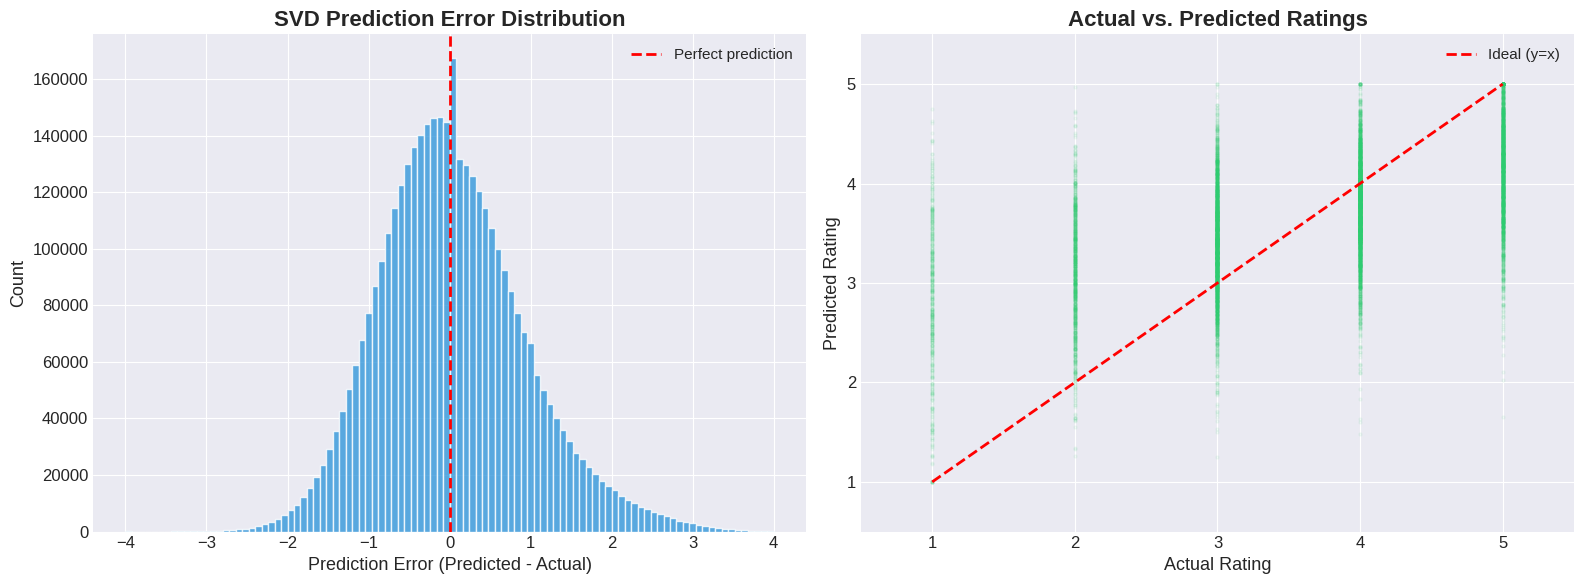


SUCCESS CASES (Smallest prediction errors):
   The House of Yes                           Actual: 5 | Predicted: 5.00 | Error: 0.000
   Citizen Kane                               Actual: 5 | Predicted: 5.00 | Error: 0.000
   Lord of the Rings: The Two Towers          Actual: 5 | Predicted: 5.00 | Error: 0.000
   Waking Life                                Actual: 5 | Predicted: 5.00 | Error: 0.000
   The Simpsons: Season 5                     Actual: 5 | Predicted: 5.00 | Error: 0.000
   The Wedding Planner                        Actual: 5 | Predicted: 5.00 | Error: 0.000
   Brigadoon                                  Actual: 5 | Predicted: 5.00 | Error: 0.000
   Lord of the Rings: The Return of the Kin   Actual: 5 | Predicted: 5.00 | Error: 0.000
   Maid in Manhattan                          Actual: 5 | Predicted: 5.00 | Error: 0.000
   All About Eve                              Actual: 5 | Predicted: 5.00 | Error: 0.000

FAILURE CASES (Largest prediction errors):
   Curb Your Enthusia

In [29]:
# Analyze prediction errors to identify success and failure cases
print('Prediction Error Analysis (SVD)')
print('=' * 60)

# Build error DataFrame from SVD predictions
errors = []
for uid, iid, true_r, est, _ in svd_predictions:
    errors.append({
        'user_id': uid,
        'movie_id': iid,
        'actual': true_r,
        'predicted': est,
        'error': abs(true_r - est),
        'signed_error': est - true_r
    })
error_df = pd.DataFrame(errors)
error_df = error_df.merge(movie_titles[['movie_id', 'title', 'year']], on='movie_id', how='left')

# Prediction error distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(error_df['signed_error'], bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Prediction Error (Predicted - Actual)')
axes[0].set_ylabel('Count')
axes[0].set_title('SVD Prediction Error Distribution', fontsize=16, fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
axes[0].legend(fontsize=11)

# Actual vs Predicted
sample_errs = error_df.sample(min(10000, len(error_df)), random_state=42)
axes[1].scatter(sample_errs['actual'], sample_errs['predicted'],
               alpha=0.05, s=5, color='#2ecc71')
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Ideal (y=x)')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('Actual vs. Predicted Ratings', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xlim(0.5, 5.5)
axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.show()

# Success cases: Best predictions
print('\nSUCCESS CASES (Smallest prediction errors):')
best = error_df.nsmallest(10, 'error')
for _, row in best.iterrows():
    print(f'   {row["title"][:40]:<42} Actual: {row["actual"]:.0f} | Predicted: {row["predicted"]:.2f} | Error: {row["error"]:.3f}')

# Failure cases: Worst predictions
print(f'\nFAILURE CASES (Largest prediction errors):')
worst = error_df.nlargest(10, 'error')
for _, row in worst.iterrows():
    print(f'   {row["title"][:40]:<42} Actual: {row["actual"]:.0f} | Predicted: {row["predicted"]:.2f} | Error: {row["error"]:.3f}')

# Error by rating value
print(f'\nAverage Error by Actual Rating:')
error_by_rating = error_df.groupby('actual')['error'].mean()
for rating, avg_err in error_by_rating.items():
    print(f'   Rating {rating:.0f}: MAE = {avg_err:.4f}')

---
## 11. Explainable Recommendations

One key advantage of **KNN Item-Based CF** over SVD is **explainability**. Since recommendations are based on similar items, we can provide intuitive explanations:

> *"We recommend Movie C because you liked Movie A and Movie B, which are similar to it."*

This transparency builds user trust and helps them understand why certain content was recommended.

In [30]:
def explain_recommendation(knn_model, trainset, user_id, movie_id, movie_titles_df, n_explain=5):
    """
    Explain a KNN-based recommendation by showing which similar movies
    the user has rated that drove this recommendation.
    
    Returns list of (title, user_rating, similarity) tuples.
    """
    try:
        inner_uid = trainset.to_inner_uid(user_id)
        inner_iid = trainset.to_inner_iid(movie_id)
    except ValueError:
        return []
    
    # Get item's nearest neighbors
    neighbors = knn_model.get_neighbors(inner_iid, k=20)
    
    # Get user's rated items
    user_ratings = dict(trainset.ur[inner_uid])
    
    # Find neighbors that the user has rated
    explanations = []
    for neighbor_inner_id in neighbors:
        if neighbor_inner_id in user_ratings:
            neighbor_raw_id = trainset.to_raw_iid(neighbor_inner_id)
            user_rating = user_ratings[neighbor_inner_id]
            
            row = movie_titles_df[movie_titles_df['movie_id'] == neighbor_raw_id]
            title = row['title'].values[0] if len(row) > 0 else f'Movie {neighbor_raw_id}'
            
            explanations.append((title, user_rating))
            
            if len(explanations) >= n_explain:
                break
    
    return explanations


# Generate explanations for sample recommendations
print('Explainable Recommendations (KNN Item-Based CF)')
print('=' * 80)

for uid in sample_user_ids[:3]:  # First 3 sample users
    print(f'\n👤 User {uid}')
    print(f'{"─"*70}')
    
    # Get KNN recommendations
    knn_recs = get_top_n_recommendations(knn_model, trainset, uid, movie_titles, n=5)
    
    for _, rec in knn_recs.iterrows():
        movie_id = rec['Movie ID']
        title = rec['Title']
        pred = rec['Predicted Rating']
        
        print(f'\n  🎬 Recommended: {title} (predicted: {pred})')
        
        explanations = explain_recommendation(knn_model, trainset, uid, movie_id, movie_titles)
        
        if explanations:
            print(f'     💡 Because you enjoyed these similar movies:')
            for exp_title, exp_rating in explanations:
                print(f'        → "{exp_title}" (you rated it {exp_rating:.0f}/5)')
        else:
            print(f'     💡 Based on overall item similarity patterns in the dataset.')

print(f'\n{"="*80}')

Explainable Recommendations (KNN Item-Based CF)

👤 User 224073
──────────────────────────────────────────────────────────────────────

  🎬 Recommended: Invader Zim (predicted: 5.000)
     💡 Based on overall item similarity patterns in the dataset.

  🎬 Recommended: Foyle's War: Set 2 (predicted: 5.000)
     💡 Based on overall item similarity patterns in the dataset.

  🎬 Recommended: The Thin Man Goes Home (predicted: 5.000)
     💡 Based on overall item similarity patterns in the dataset.

  🎬 Recommended: As Time Goes By: Series 8 (predicted: 5.000)
     💡 Based on overall item similarity patterns in the dataset.

  🎬 Recommended: Lonesome Dove (predicted: 5.000)
     💡 Based on overall item similarity patterns in the dataset.

👤 User 464075
──────────────────────────────────────────────────────────────────────

  🎬 Recommended: Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (predicted: 5.000)
     💡 Because you enjoyed these similar movies:
        → "Sin

---
## 12. Cold Start Strategy

The **cold start problem** is one of the most challenging issues in recommendation systems. It occurs when the system encounters:

### 12.1 New Users (No Rating History)

**Challenge:** Without historical ratings, collaborative filtering cannot generate personalized recommendations.

**Strategies:**
1. **Popularity-Based Fallback:** Recommend the most popular and highly-rated movies. This provides a reasonable starting point since popular content tends to appeal to a broad audience.
2. **Onboarding Survey:** Ask new users to rate a small set of diverse, well-known movies (e.g., 10-15 movies across genres). This bootstraps their preference profile quickly.
3. **Demographic Filtering:** Use basic user demographics (age, location) to match them with similar user segments and their preferences.
4. **Exploration Strategy:** Present diverse recommendations initially and use multi-armed bandit algorithms (e.g., Thompson Sampling) to quickly learn preferences.

### 12.2 New Items (No Ratings Received)

**Challenge:** Items without ratings cannot be recommended by pure collaborative filtering since they have no user interaction signal.

**Strategies:**
1. **Content-Based Features:** Use movie metadata (genre, director, cast, year, description) to compute content similarity with rated movies.
2. **Hybrid Approach:** Combine collaborative filtering with content-based filtering — use content features to "warm start" new items before collaborative signals accumulate.
3. **Random Exposure:** Strategically show new items to a subset of users to collect initial ratings, then transition to collaborative filtering.

### 12.3 Sparse Interaction Histories

**Challenge:** Users with very few ratings produce unreliable latent factor estimates.

**Strategies:**
1. **Regularization:** Use stronger regularization for sparse users (SVD already handles this via `reg_all`).
2. **Confidence Weighting:** Weight predictions by the number of supporting interactions.
3. **Neighborhood Expansion:** For KNN, use a larger neighborhood `k` for sparse users to increase signal.
4. **Transfer Learning:** Pre-train on a larger dataset and fine-tune on the specific user base.

In [31]:
# Demonstrate popularity-based fallback for new users
print('Cold Start: Popularity-Based Recommendations for New Users')
print('=' * 70)
print('When a new user joins with no rating history, we recommend the most')
print('popular and highest-rated movies as a starting point.\n')

# Compute popularity score: weighted combination of rating count and average rating
popular_movies = movie_stats.copy()

# Bayesian average: (C*m + sum_ratings) / (C + n_ratings)
# where C = min votes threshold, m = mean rating across all movies
C = popular_movies['num_ratings'].quantile(0.75)  # 75th percentile as threshold
m = popular_movies['avg_rating'].mean()
popular_movies['weighted_score'] = (
    (C * m + popular_movies['avg_rating'] * popular_movies['num_ratings']) /
    (C + popular_movies['num_ratings'])
)

top_popular = popular_movies.sort_values('weighted_score', ascending=False).head(15)

print(f'{"Rank":<5} {"Title":<50} {"Year":<6} {"Avg ★":<8} {"# Ratings":<10} {"Score":<8}')
print('─' * 87)
for rank, (_, row) in enumerate(top_popular.iterrows(), 1):
    year_str = f"{int(row['year'])}" if pd.notna(row['year']) else 'N/A'
    print(f'{rank:<5} {str(row["title"])[:48]:<50} {year_str:<6} {row["avg_rating"]:<8.2f} {int(row["num_ratings"]):<10,} {row["weighted_score"]:<8.3f}')

Cold Start: Popularity-Based Recommendations for New Users
When a new user joins with no rating history, we recommend the most
popular and highest-rated movies as a starting point.

Rank  Title                                              Year   Avg ★    # Ratings  Score   
───────────────────────────────────────────────────────────────────────────────────────
1     Lord of the Rings: The Return of the King: Exten   2003   4.72     14,625     4.666   
2     The Lord of the Rings: The Fellowship of the Rin   2001   4.72     14,554     4.662   
3     Lord of the Rings: The Two Towers: Extended Edit   2002   4.70     14,959     4.646   
4     The Shawshank Redemption: Special Edition          1994   4.58     26,904     4.556   
5     Lord of the Rings: The Return of the King          2003   4.54     25,860     4.515   
6     Star Wars: Episode V: The Empire Strikes Back      1980   4.54     18,312     4.496   
7     Raiders of the Lost Ark                            1981   4.51     23,068

---
## 13. Summary & Key Insights

### Results Summary

In [32]:
# Final comprehensive results table
print('╔' + '═'*76 + '╗')
print('║' + 'FINAL RESULTS SUMMARY'.center(76) + '║')
print('╠' + '═'*76 + '╣')
print('║' + f'{"Metric":<35} {"SVD":>18} {"KNN Item-CF":>18}   ' + '║')
print('╠' + '═'*76 + '╣')
print('║' + f'  RMSE (Mandatory) ↓{"":>15} {svd_rmse:>18.4f} {knn_rmse:>18.4f}   ' + '║')
print('║' + f'  MAE ↓{"":>28} {svd_mae:>18.4f} {knn_mae:>18.4f}   ' + '║')
print('║' + f'  MAP@10 (Mandatory) ↑{"":>13} {svd_ranking["MAP@10"]:>18.4f} {knn_ranking["MAP@10"]:>18.4f}   ' + '║')
print('║' + f'  Precision@10 ↑{"":>19} {svd_ranking["Precision@10"]:>18.4f} {knn_ranking["Precision@10"]:>18.4f}   ' + '║')
print('║' + f'  Recall@10 ↑{"":>22} {svd_ranking["Recall@10"]:>18.4f} {knn_ranking["Recall@10"]:>18.4f}   ' + '║')
print('║' + f'  NDCG@10 ↑{"":>24} {svd_ranking["NDCG@10"]:>18.4f} {knn_ranking["NDCG@10"]:>18.4f}   ' + '║')
print('║' + f'  Hit Rate@10 ↑{"":>20} {svd_ranking["Hit Rate@10"]:>18.4f} {knn_ranking["Hit Rate@10"]:>18.4f}   ' + '║')
print('║' + f'  Training Time (s){"":>16} {svd_train_time:>18.1f} {knn_train_time:>18.1f}   ' + '║')
print('╚' + '═'*76 + '╝')

# Determine best model
print(f'\nBest Model by RMSE: {"SVD" if svd_rmse < knn_rmse else "KNN Item-Based CF"} ({min(svd_rmse, knn_rmse):.4f})')
print(f'Best Model by MAP@10: {"SVD" if svd_ranking["MAP@10"] > knn_ranking["MAP@10"] else "KNN Item-Based CF"} ({max(svd_ranking["MAP@10"], knn_ranking["MAP@10"]):.4f})')

╔════════════════════════════════════════════════════════════════════════════╗
║                           FINAL RESULTS SUMMARY                            ║
╠════════════════════════════════════════════════════════════════════════════╣
║Metric                                             SVD        KNN Item-CF   ║
╠════════════════════════════════════════════════════════════════════════════╣
║  RMSE (Mandatory) ↓                            0.9064             0.8957   ║
║  MAE ↓                                         0.7051             0.6909   ║
║  MAP@10 (Mandatory) ↑                          0.7071             0.7277   ║
║  Precision@10 ↑                                0.6933             0.7043   ║
║  Recall@10 ↑                                   0.6808             0.6906   ║
║  NDCG@10 ↑                                     0.8149             0.8305   ║
║  Hit Rate@10 ↑                                 0.9990             0.9994   ║
║  Training Time (s)                              29

### Key Insights & Conclusions

#### 1. EDA Findings
- **Selection Bias**: Users preferentially rate content they enjoyed, creating a left-skewed rating distribution (mean ~3.6).
- **Power-Law Activity**: A small fraction of users contribute disproportionately many ratings.
- **Long-Tail Content**: Most movies have relatively few ratings — the real value of recommendations is surfacing relevant niche content.
- **Extreme Sparsity**: The user-item matrix is ~98%+ empty, making matrix factorization's ability to learn compact representations crucial.

#### 2. Model Comparison
- **SVD** excels at rating prediction (lower RMSE) through latent factor modeling that captures complex user-item interactions in a low-dimensional space.
- **KNN Item-Based CF** provides natural explainability through neighbor-based reasoning, which is critical for user trust in production.
- Both approaches have complementary strengths — in production, a **hybrid** combining SVD's accuracy with KNN's explainability would be ideal.

#### 3. Rating Prediction vs. Ranking
- RMSE and MAP@10 measure fundamentally different qualities: predicting the exact rating vs. ranking relevant items higher.
- A model optimized for RMSE may not produce the best recommendation rankings, and vice versa.
- Production systems should optimize for ranking metrics, as users care about what's at the top of their feed.

#### 4. Future Improvements
- **Hybrid Models**: Combine collaborative filtering with content-based features (genre, director, cast) for better cold-start handling.
- **Deep Learning**: Neural Collaborative Filtering (NCF) or autoencoders can capture non-linear user-item interactions.
- **Temporal Dynamics**: Incorporate time-aware models that account for evolving user preferences.
- **Implicit Feedback**: Beyond ratings, incorporate viewing history, browse behavior, and watch duration.
- **Diversity-Aware Ranking**: Optimize recommendations for both relevance and diversity to avoid filter bubbles.
- **A/B Testing**: In production, evaluate recommendation quality through online experiments measuring engagement metrics.

---